# Terridata analysis

In [1]:
import re
import unicodedata
from scipy.stats import pearsonr, spearmanr # type: ignore
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm # type: ignore

In [2]:
# General functions
import os
import pandas as pd # type: ignore
import numpy as np # type: ignore
import ETL as etl

# Get query files function
def get_path(folder, file_path):
    current_directory = os.getcwd()
    return os.path.join(current_directory, '..', folder, file_path)


def get_query(folder, file_path):
    path = get_path(folder, file_path)
    # try to get the query
    with open(path, "r", encoding="utf8") as query_file:
        query = query_file.read()
    
    return query

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)


In [3]:
path = get_path('data', 'collected_obra_data_v3_1.csv')

data_contracts = pd.read_csv(path)
data_contracts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 238 entries, 0 to 237
Data columns (total 69 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   CONTRACT_ID                              238 non-null    object 
 1   ENTITY_NAME                              238 non-null    object 
 2   DEPARTMENT                               238 non-null    object 
 3   MUNICIPALITY_TYPE                        238 non-null    object 
 4   PROCESS_TYPE                             238 non-null    object 
 5   CONTRACT_OBJECT                          238 non-null    object 
 6   OBJETC_DETAIL                            238 non-null    object 
 7   ESTIMATED_COST_ORIG                      238 non-null    float64
 8   CONTRACT_VALUE_ORIG                      238 non-null    float64
 9   ADDITIONAL_COST_ORIG                     238 non-null    float64
 10  FINAL_COST_ORIG                          238 non-n

In [4]:
path = get_path('data', 'TerriData.txt.zip')

col_names = ['DEPARTMENT', 'COD_DEPT', 'MUNICIPALITY', 'DIMENSION', 'SUBCATEGORY',
              'KPI','COD_MUN', 'VALUE_NUMERIC', 'VALUE_CUALITATIVE', 'YEAR',
              'MONTH', 'SOURCE', 'UNITS']

dtypes = {'DEPARTMENT':'object', 'COD_DEPT':'int32', 'MUNICIPALITY':'object', 'DIMENSION':'object', 'SUBCATEGORY':'object',
              'KPI':'object', 'COD_MUN':'object', 'VALUE_NUMERIC':'object', 'VALUE_CUALITATIVE':'object', 'YEAR':'int32',
              'MONTH':'int32', 'SOURCE':'object', 'UNITS':'object'}

terridata = pd.read_csv(path, sep = '|', encoding='utf-8', header=None, names=col_names, dtype=dtypes)
terridata.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10485378 entries, 1 to 5
Data columns (total 13 columns):
 #   Column             Dtype 
---  ------             ----- 
 0   DEPARTMENT         object
 1   COD_DEPT           int32 
 2   MUNICIPALITY       object
 3   DIMENSION          object
 4   SUBCATEGORY        object
 5   KPI                object
 6   COD_MUN            object
 7   VALUE_NUMERIC      object
 8   VALUE_CUALITATIVE  object
 9   YEAR               int32 
 10  MONTH              int32 
 11  SOURCE             object
 12  UNITS              object
dtypes: int32(3), object(10)
memory usage: 1000.0+ MB


In [5]:
terridata['VALUE_NUMERIC'] = terridata['VALUE_NUMERIC'].str.replace('.','').str.replace(',','.')
terridata['VALUE_NUMERIC'] = terridata['VALUE_NUMERIC'].astype(float)

terridata = terridata[(terridata['YEAR'] >= 2014) & (terridata['YEAR'] <= 2023)]
terridata = terridata[terridata['VALUE_NUMERIC'].notnull()]

cods = data_contracts['MUN_COD_EJECUTION'].drop_duplicates().values
terridata = terridata[terridata['COD_DEPT'].isin(cods)]

In [6]:
terridata.info()

<class 'pandas.core.frame.DataFrame'>
Index: 594319 entries, 5 to 5
Data columns (total 13 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   DEPARTMENT         594319 non-null  object 
 1   COD_DEPT           594319 non-null  int32  
 2   MUNICIPALITY       594319 non-null  object 
 3   DIMENSION          594319 non-null  object 
 4   SUBCATEGORY        594319 non-null  object 
 5   KPI                594319 non-null  object 
 6   COD_MUN            594319 non-null  object 
 7   VALUE_NUMERIC      594319 non-null  float64
 8   VALUE_CUALITATIVE  14152 non-null   object 
 9   YEAR               594319 non-null  int32  
 10  MONTH              594319 non-null  int32  
 11  SOURCE             594319 non-null  object 
 12  UNITS              593884 non-null  object 
dtypes: float64(1), int32(3), object(9)
memory usage: 56.7+ MB


In [7]:
def summary_year(x):
    data = {}
    data['VALUE_NUMERIC_YEARLY'] = x['VALUE_NUMERIC'].mean()

    return pd.Series(data)

main_cols = ['DIMENSION', 'SUBCATEGORY', 'KPI', 'COD_DEPT', 'YEAR', 'SOURCE', 'UNITS']

terridata = terridata.groupby(main_cols).apply(summary_year).reset_index()

In [8]:
terridata.head()

,DIMENSION,SUBCATEGORY,KPI,COD_DEPT,YEAR,SOURCE,UNITS,VALUE_NUMERIC_YEARLY
0,Ambiente,Biodiversidad y servicios ecosistémicos: Bosque y deforestación,Porcentaje del área departamental de bosque que se encuentra en el municipio,5001,2014,DNP a partir de información del IDEAM,Porcentaje (el valor está multiplicado por 100),0.36
1,Ambiente,Biodiversidad y servicios ecosistémicos: Bosque y deforestación,Porcentaje del área departamental de bosque que se encuentra en el municipio,5001,2015,DNP a partir de información del IDEAM,Porcentaje (el valor está multiplicado por 100),0.37
2,Ambiente,Biodiversidad y servicios ecosistémicos: Bosque y deforestación,Porcentaje del área departamental de bosque que se encuentra en el municipio,5001,2016,DNP a partir de información del IDEAM,Porcentaje (el valor está multiplicado por 100),0.37
3,Ambiente,Biodiversidad y servicios ecosistémicos: Bosque y deforestación,Porcentaje del área departamental de bosque que se encuentra en el municipio,5034,2014,DNP a partir de información del IDEAM,Porcentaje (el valor está multiplicado por 100),0.75
4,Ambiente,Biodiversidad y servicios ecosistémicos: Bosque y deforestación,Porcentaje del área departamental de bosque que se encuentra en el municipio,5034,2015,DNP a partir de información del IDEAM,Porcentaje (el valor está multiplicado por 100),0.74


# Generalización de indicadores

In [10]:
col_kpis = ['DIMENSION', 'SUBCATEGORY', 'KPI','SOURCE', 'UNITS']
base_kpis = terridata[col_kpis].drop_duplicates()
base_kpis['KEY'] = base_kpis['DIMENSION'] + ' - ' + base_kpis['SUBCATEGORY'] + ' - ' + base_kpis['KPI']

In [11]:
base_kpis = base_kpis.set_index('KEY')
base_kpis['DIFF_YEARS'] = ''
base_kpis['MIN_YEAR'] = ''
base_kpis['MAX_YEAR'] = ''
base_kpis['MEAN'] = ''
base_kpis['MEDIAN'] = ''
base_kpis['STD'] = ''
base_kpis['MIN'] = ''
base_kpis['MAX'] = ''
base_kpis['COUNT'] = ''
base_kpis['SIG_CORRELATION_PEARSON'] = ''
base_kpis['BREAKDOWN_PEARSON'] = ''
base_kpis['SIG_CORRELATION_SPEARMAN'] = ''
base_kpis['BREAKDOWN_SPEARMAN'] = ''

In [12]:
indicadores  = base_kpis.index.to_list()

for indicador_key in indicadores:

    indicador = base_kpis[base_kpis.index == indicador_key]

    terridata_sub = terridata[(terridata['KPI'].isin(indicador['KPI'].values)) & 
                          (terridata['SUBCATEGORY'].isin(indicador['SUBCATEGORY'].values)) & 
                          (terridata['DIMENSION'].isin(indicador['DIMENSION'].values))]

    data_contracts_sub = pd.merge(data_contracts, terridata_sub, how='inner', left_on=['MUN_COD_EJECUTION', 'YEAR'], right_on=['COD_DEPT', 'YEAR'])

    base_kpis.loc[indicador_key, 'DIFF_YEARS'] = len(data_contracts_sub['YEAR'].drop_duplicates())
    base_kpis.loc[indicador_key, 'MIN_YEAR'] = data_contracts_sub['YEAR'].min()
    base_kpis.loc[indicador_key, 'MAX_YEAR'] = data_contracts_sub['YEAR'].max()
    base_kpis.loc[indicador_key, 'MEAN'] = data_contracts_sub['VALUE_NUMERIC_YEARLY'].mean()
    base_kpis.loc[indicador_key, 'MEDIAN'] = data_contracts_sub['VALUE_NUMERIC_YEARLY'].median()
    base_kpis.loc[indicador_key, 'STD'] = data_contracts_sub['VALUE_NUMERIC_YEARLY'].std()
    base_kpis.loc[indicador_key, 'MIN'] = data_contracts_sub['VALUE_NUMERIC_YEARLY'].min()
    base_kpis.loc[indicador_key, 'MAX'] = data_contracts_sub['VALUE_NUMERIC_YEARLY'].max()
    base_kpis.loc[indicador_key, 'COUNT'] = len(data_contracts_sub[data_contracts_sub['VALUE_NUMERIC_YEARLY'].notnull()])

    pearson_correlations = {}
    cont = 0
    interested_var = ['CONTRACT_VALUE_NORM', 'ADDITIONAL_COST_NORM',
                        'ORIGINAL_DEADLINE', 'ADDITIONAL_TIME',
                        'PROJECT_INTENSITY_NORM', 'AWARD_GROWTH_NORM',
                        'NUM_PENALTIES_ENTIDAD_LAST_Y', 'PROPORTION_DEVIATIONS_ENTIDAD_LAST_Y',
                        'PROJECT_INTENSITY_NORM_LAST_Y', 'AWARD_GROWTH_ORIG_LAST_Y',
                        'PROPORTION_DEVIATIONS_CONT_LAST_Y', 'PROJECT_INTENSITY_NORM_CONT_LAST_Y',
                        'AWARD_GROWTH_ORIG_LAST_CONT_Y']

    x = 'VALUE_NUMERIC_YEARLY'

    alpha = .05

    for y in interested_var:
        
        sub = data_contracts_sub[[x,y]].dropna()

        if len(sub) > 50:

            corr, p_value = pearsonr(sub[x], sub[y])
            pearson_correlations[y] = {'corr':np.round(corr,4), 'p_value': np.round(p_value,4)}
            if p_value < alpha:
                cont = cont + 1
        
    pearson_correlations['variables_sig'] = cont

    spearman_correlations = {}
    cont = 0

    for y in interested_var:
        
        sub = data_contracts_sub[[x,y]].dropna()
        
        if len(sub) > 50:

            corr, p_value = spearmanr(sub[x], sub[y])
            spearman_correlations[y] = {'corr':np.round(corr,4), 'p_value': np.round(p_value,4)}
            if p_value < alpha:
                cont = cont + 1
        
    spearman_correlations['variables_sig'] = cont

    base_kpis.loc[indicador_key, 'SIG_CORRELATION_PEARSON'] = pearson_correlations['variables_sig']
    base_kpis.loc[indicador_key, 'SIG_CORRELATION_SPEARMAN'] = spearman_correlations['variables_sig']
    base_kpis.loc[indicador_key, 'BREAKDOWN_PEARSON'] = str(pearson_correlations)
    base_kpis.loc[indicador_key, 'BREAKDOWN_SPEARMAN'] = str(spearman_correlations)

KeyError: "['PROPORTION_DEVIATIONS_ENTIDAD_LAST_Y'] not in index"

In [38]:
base_kpis.to_csv(get_path('data', 'terridata_summary.csv'), index=False)
base_kpis.to_csv(get_path('data', 'terridata_summary_excel.csv'), index=False, sep=';', decimal=',')

In [39]:
data_contracts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 237 entries, 0 to 236
Data columns (total 67 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   CONTRACT_ID                           237 non-null    object 
 1   ENTITY_NAME                           237 non-null    object 
 2   DEPARTMENT                            237 non-null    object 
 3   MUNICIPALITY_TYPE                     237 non-null    object 
 4   PROCESS_TYPE                          237 non-null    object 
 5   CONTRACT_OBJECT                       237 non-null    object 
 6   OBJETC_DETAIL                         237 non-null    object 
 7   ESTIMATED_COST_ORIG                   237 non-null    float64
 8   CONTRACT_VALUE_ORIG                   237 non-null    float64
 9   ADDITIONAL_COST_ORIG                  237 non-null    float64
 10  FINAL_COST_ORIG                       237 non-null    float64
 11  YEAR               

In [40]:
dimensiones = ['Finanzas públicas', 'Medición de desempeño municipal']

base_selection = base_kpis[(base_kpis['DIMENSION'].isin(dimensiones)) & 
                            ((base_kpis['SIG_CORRELATION_PEARSON'] > 1) | (base_kpis['SIG_CORRELATION_SPEARMAN'] > 1))]

y_variables = ['HAVE_DEVIATION_COST', 'HAVE_DEVIATION_TIME', 'COST_DEVIATION_NORM', 'TIME_DEVIATION']

In [41]:
indicadores  = base_selection.index.to_list()

#indicador_key = 'Finanzas públicas - Operaciones efectivas de caja - Funcionamiento'

for indicador_key in indicadores:
    indicador = base_selection[base_selection.index == indicador_key]

    terridata_sub = terridata[(terridata['KPI'].isin(indicador['KPI'].values)) & 
                            (terridata['SUBCATEGORY'].isin(indicador['SUBCATEGORY'].values)) & 
                            (terridata['DIMENSION'].isin(indicador['DIMENSION'].values))]

    data_contracts_sub = pd.merge(data_contracts, terridata_sub, how='inner', left_on=['MUN_COD_EJECUTION', 'YEAR'], right_on=['COD_DEPT', 'YEAR'])

    for y_label in y_variables:

        x_label = 'VALUE_NUMERIC_YEARLY'

        if y_label in ['HAVE_DEVIATION_COST', 'HAVE_DEVIATION_TIME']:
            y = data_contracts_sub[y_label].astype(int).to_list()
            x = data_contracts_sub[x_label].to_list()

            X_with_constant = sm.add_constant(x)

            model = sm.Logit(y, X_with_constant)
            result = model.fit()
        else:
            y = data_contracts_sub[y_label].to_list()
            x = data_contracts_sub[x_label].to_list()

            X_with_constant = sm.add_constant(x)

            model = sm.OLS(y, X_with_constant)
            result = model.fit()

        pvalue = result.pvalues[1]

        coefficient = result.params[1]

        pvalue_sig = pvalue < 0.05

        base_selection.loc[indicador_key, 'PVALUE_' + y_label] = pvalue
        base_selection.loc[indicador_key, 'PVALUE_SIG_' + y_label] = int(pvalue_sig)
        base_selection.loc[indicador_key, 'COEFFICIENT_' + y_label] = coefficient

Optimization terminated successfully.
         Current function value: 0.586510
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.646182
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.565159
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.611545
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.553986
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.593892
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.568814
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.630308
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.579459
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.637723
  

C:\Users\nicolas.arrieta\AppData\Local\Temp\ipykernel_12988\2137716573.py:41: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  base_selection.loc[indicador_key, 'PVALUE_' + y_label] = pvalue
C:\Users\nicolas.arrieta\AppData\Local\Temp\ipykernel_12988\2137716573.py:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  base_selection.loc[indicador_key, 'PVALUE_SIG_' + y_label] = int(pvalue_sig)
C:\Users\nicolas.arrieta\AppData\Local\Temp\ipykernel_12988\2137716573.py:43: SettingWithCopyWarning: 
A value is trying to

Optimization terminated successfully.
         Current function value: 0.565572
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.611709
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.586717
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.650925
         Iterations 4
Optimization terminated successfully.
         Current function value: 0.583108
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.611005
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.579367
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.629347
         Iterations 4
Optimization terminated successfully.
         Current function value: 0.583381
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.622064
  

c:\Users\nicolas.arrieta\anaconda3\envs\hospital_procurement_data\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\nicolas.arrieta\anaconda3\envs\hospital_procurement_data\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Optimization terminated successfully.
         Current function value: 0.566334
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.622828
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.576860
         Iterations 8
Optimization terminated successfully.
         Current function value: 0.630810
         Iterations 4
Optimization terminated successfully.
         Current function value: 0.577629
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.626295
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.583556
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.625723
         Iterations 4
Optimization terminated successfully.
         Current function value: 0.575098
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.626536
  

In [42]:
base_selection.to_csv(get_path('data', 'terridata_summary_v2.csv'), index=False)
base_selection.to_csv(get_path('data', 'terridata_summary_v2_excel.csv'), index=False, sep=';', decimal=',')

## Análisis espécifico

In [13]:
indicador_key = 'Finanzas públicas - Operaciones efectivas de caja - Indicador de desempeño fiscal'

indicador = base_kpis[base_kpis.index == indicador_key]

terridata_sub = terridata[(terridata['KPI'].isin(indicador['KPI'].values)) & 
                        (terridata['SUBCATEGORY'].isin(indicador['SUBCATEGORY'].values)) & 
                        (terridata['DIMENSION'].isin(indicador['DIMENSION'].values))]

data_contracts_sub = pd.merge(data_contracts, terridata_sub, how='inner', left_on=['MUN_COD_EJECUTION', 'YEAR'], right_on=['COD_DEPT', 'YEAR'])

interested_var = ['COST_DEVIATION_NORM', 'TIME_DEVIATION']

x = 'VALUE_NUMERIC_YEARLY'

interested_var.append(x)

data_contracts_sub = data_contracts_sub[interested_var]

interested_var.remove(x)

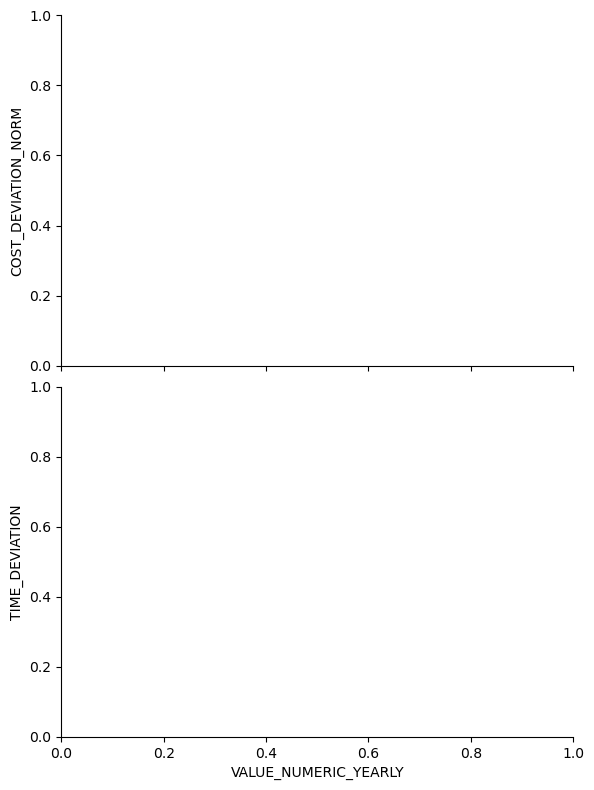

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

# Adjust the height and aspect ratio
height = 4  # Height of each plot
aspect = 1.5  # Aspect ratio (width/height)

# Initialize the PairGrid with X and Y variables
g = sns.PairGrid(data_contracts_sub, x_vars=[x], y_vars=interested_var,  height=height, aspect=aspect)


# Define a custom function to apply different y-axis limits
def custom_scatter(x, y, **kwargs):
    plt.scatter(x, y, **kwargs)
    plt.ylim([min(y) - (max(y) - min(y)) * 0.1, max(y) + (max(y) - min(y)) * 0.1])  # Custom y-axis limits based on data range

# Map the custom scatter plot function to each subplot
# g.map(custom_scatter)

# Adjust layout and show plot
g.tight_layout()
plt.show()

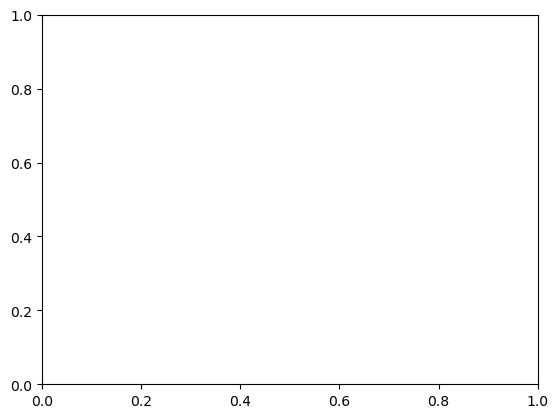

In [45]:
sns.scatterplot(data=data_contracts_sub, x='COST_DEVIATION_NORM', y='VALUE_NUMERIC_YEARLY')
plt.show()

## Extracción de variables importantes

In [9]:
col_kpis = ['DIMENSION', 'SUBCATEGORY', 'KPI','SOURCE', 'UNITS']
base_kpis = terridata[col_kpis].drop_duplicates()
base_kpis['KEY'] = base_kpis['DIMENSION'] + ' - ' + base_kpis['SUBCATEGORY'] + ' - ' + base_kpis['KPI']

In [10]:
indicadores_interest = ['Economía - Valor agregado municipal - Valor agregado',
'Finanzas públicas - Desempeño fiscal - Indicador de desempeño fiscal',
'Medición de desempeño municipal - Componente de gestión - Gobierno abierto y transparencia',
'Finanzas públicas - Inversión por sectores - Inversión - Transporte',
'Finanzas públicas - Nuevo Índice de Desempeño Fiscal - Puntaje nuevo Índice de Desempeño Fiscal']

In [20]:
indicadores_interest = ['Economía - Valor agregado - Base 2015 - Industria manufacturera',
'Economía - Valor agregado - Base 2015 - Valor agregado per cápita',
'Economía - Valor agregado - Base 2015 - Transporte, almacenamiento y comunicaciones',
'Economía - Valor agregado - Base 2015 - Construcción']

In [21]:
indicador = base_kpis[base_kpis['KEY'].isin(indicadores_interest)]

In [22]:
indicador

,DIMENSION,SUBCATEGORY,KPI,SOURCE,UNITS,KEY
310181,Economía,Valor agregado - Base 2015,Construcción,DNP a partir de información del DANE,Porcentaje (el valor está multiplicado por 100),Economía - Valor agregado - Base 2015 - Construcción
311081,Economía,Valor agregado - Base 2015,Industria manufacturera,DNP a partir de información del DANE,Porcentaje (el valor está multiplicado por 100),Economía - Valor agregado - Base 2015 - Industria manufacturera
311981,Economía,Valor agregado - Base 2015,"Transporte, almacenamiento y comunicaciones",DNP a partir de información del DANE,Porcentaje (el valor está multiplicado por 100),"Economía - Valor agregado - Base 2015 - Transporte, almacenamiento y comunicaciones"
312581,Economía,Valor agregado - Base 2015,Valor agregado per cápita,DNP a partir de información propia y del DANE,Pesos corrientes,Economía - Valor agregado - Base 2015 - Valor agregado per cápita


In [13]:
terridata_sub = terridata[(terridata['KPI'].isin(indicador['KPI'].values)) & 
                          (terridata['SUBCATEGORY'].isin(indicador['SUBCATEGORY'].values)) & 
                          (terridata['DIMENSION'].isin(indicador['DIMENSION'].values))]

original_indicador_name = indicador['KPI'].to_list()

new_indicador_name = ['ECONOMIC_IMPORTANCE', 'FISCAL_DESEMPENO_1', 'TRANSPORT_INVESTMENT', 'FISCAL_DESEMPENO_2', 'OPEN_TRANSPARENCE_GOBERMENT']
terridata_sub['KPI_NEW'] = terridata_sub['KPI'].replace(original_indicador_name, new_indicador_name)
terridata_sub.groupby('KPI_NEW').size()

terridata_sub = terridata_sub[['KPI_NEW', 'COD_DEPT', 'YEAR', 'VALUE_NUMERIC_YEARLY']]

C:\Users\nicolas.arrieta\AppData\Local\Temp\ipykernel_10516\1677258212.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  terridata_sub['KPI_NEW'] = terridata_sub['KPI'].replace(original_indicador_name, new_indicador_name)


In [23]:
terridata_sub = terridata[(terridata['KPI'].isin(indicador['KPI'].values)) & 
                          (terridata['SUBCATEGORY'].isin(indicador['SUBCATEGORY'].values)) & 
                          (terridata['DIMENSION'].isin(indicador['DIMENSION'].values))]

original_indicador_name = indicador['KPI'].to_list()

new_indicador_name = ['CONTRUCTION_ECONOMIC', 'INDUSTRIAL_ECONOMIC', 'TRANSPORT_ECONOMIC', 'IMPORTANCE_ECONOMIC_PERCAPITAL']
terridata_sub['KPI_NEW'] = terridata_sub['KPI'].replace(original_indicador_name, new_indicador_name)
terridata_sub.groupby('KPI_NEW').size()

terridata_sub = terridata_sub[['KPI_NEW', 'COD_DEPT', 'YEAR', 'VALUE_NUMERIC_YEARLY']]
terridata_sub

C:\Users\nicolas.arrieta\AppData\Local\Temp\ipykernel_10516\1894948118.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  terridata_sub['KPI_NEW'] = terridata_sub['KPI'].replace(original_indicador_name, new_indicador_name)


,KPI_NEW,COD_DEPT,YEAR,VALUE_NUMERIC_YEARLY
310181,CONTRUCTION_ECONOMIC,5001,2014,13.73
310182,CONTRUCTION_ECONOMIC,5001,2015,12.64
310183,CONTRUCTION_ECONOMIC,5034,2014,13.75
310184,CONTRUCTION_ECONOMIC,5034,2015,12.57
310185,CONTRUCTION_ECONOMIC,5036,2014,13.82
...,...,...,...,...
312876,IMPORTANCE_ECONOMIC_PERCAPITAL,86757,2015,6231033.07
312877,IMPORTANCE_ECONOMIC_PERCAPITAL,95001,2014,6900035.46
312878,IMPORTANCE_ECONOMIC_PERCAPITAL,95001,2015,7375998.36
312879,IMPORTANCE_ECONOMIC_PERCAPITAL,95025,2014,4318155.40


In [24]:
terridata_sub = terridata_sub[terridata_sub['YEAR'] == 2015]
terridata_sub = terridata_sub.drop('YEAR', axis=1)

In [25]:
# pivot_terridata = terridata_sub.pivot(index=['COD_DEPT','YEAR'], columns='KPI_NEW', values='VALUE_NUMERIC_YEARLY').reset_index()

pivot_terridata = terridata_sub.pivot(index=['COD_DEPT'], columns='KPI_NEW', values='VALUE_NUMERIC_YEARLY').reset_index()
# pivot_terridata = pivot_terridata[['COD_DEPT', 'CONTRUCTION_ECONOMIC', 'INDUSTRIAL_ECONOMIC', 'TRANSPORT_ECONOMIC', 'IMPORTANCE_ECONOMIC_PERCAPITAL']]

pivot_terridata.head()

KPI_NEW,COD_DEPT,CONTRUCTION_ECONOMIC,IMPORTANCE_ECONOMIC_PERCAPITAL,INDUSTRIAL_ECONOMIC,TRANSPORT_ECONOMIC
0,5001,12.64,17977982.36,12.22,5.81
1,5034,12.57,13786400.43,16.77,7.44
2,5036,12.64,8212364.40,0.47,12.21
3,5038,12.64,10248529.57,8.05,9.87
4,5044,12.64,7790870.26,1.24,12.85


In [27]:
# data_contracts_sub = pd.merge(data_contracts_sub, pivot_terridata, how='left', left_on=['MUN_COD_EJECUTION','YEAR'], right_on=['COD_DEPT','YEAR'])
data_contracts_sub = pd.merge(data_contracts_sub, pivot_terridata, how='left', left_on=['MUN_COD_EJECUTION'], right_on=['COD_DEPT'])

In [33]:
data_contracts_sub.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 238 entries, 0 to 237
Data columns (total 77 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   CONTRACT_ID                              238 non-null    object 
 1   ENTITY_NAME                              238 non-null    object 
 2   DEPARTMENT                               238 non-null    object 
 3   MUNICIPALITY_TYPE                        238 non-null    object 
 4   PROCESS_TYPE                             238 non-null    object 
 5   CONTRACT_OBJECT                          238 non-null    object 
 6   OBJETC_DETAIL                            238 non-null    object 
 7   ESTIMATED_COST_ORIG                      238 non-null    float64
 8   CONTRACT_VALUE_ORIG                      238 non-null    float64
 9   ADDITIONAL_COST_ORIG                     238 non-null    float64
 10  FINAL_COST_ORIG                          238 non-n

In [29]:
# Fill the missing values in 'var1' with the mean of 'var1'
data_contracts_sub['CONTRUCTION_ECONOMIC'] = data_contracts_sub['CONTRUCTION_ECONOMIC'].fillna(data_contracts_sub['CONTRUCTION_ECONOMIC'].mean())
data_contracts_sub['INDUSTRIAL_ECONOMIC'] = data_contracts_sub['INDUSTRIAL_ECONOMIC'].fillna(data_contracts_sub['INDUSTRIAL_ECONOMIC'].mean())
data_contracts_sub['TRANSPORT_ECONOMIC'] = data_contracts_sub['TRANSPORT_ECONOMIC'].fillna(data_contracts_sub['TRANSPORT_ECONOMIC'].mean())
data_contracts_sub['IMPORTANCE_ECONOMIC_PERCAPITAL'] = data_contracts_sub['IMPORTANCE_ECONOMIC_PERCAPITAL'].fillna(data_contracts_sub['IMPORTANCE_ECONOMIC_PERCAPITAL'].mean())

In [17]:
data_contracts_sub['ECONOMIC_IMPORTANCE'] = data_contracts_sub['ECONOMIC_IMPORTANCE'].fillna(data_contracts_sub['ECONOMIC_IMPORTANCE'].mean())
data_contracts_sub['FISCAL_DESEMPENO'] = data_contracts_sub[['FISCAL_DESEMPENO_1','FISCAL_DESEMPENO_2']].mean(axis=1)
data_contracts_sub['FISCAL_DESEMPENO'] = data_contracts_sub['FISCAL_DESEMPENO'].fillna(data_contracts_sub['FISCAL_DESEMPENO'].mean())
data_contracts_sub['OPEN_TRANSPARENCE_GOBERMENT'] = data_contracts_sub['OPEN_TRANSPARENCE_GOBERMENT'].fillna(data_contracts_sub['OPEN_TRANSPARENCE_GOBERMENT'].mean())
data_contracts_sub['TRANSPORT_INVESTMENT'] = data_contracts_sub['TRANSPORT_INVESTMENT'].fillna(data_contracts_sub['TRANSPORT_INVESTMENT'].mean())

In [30]:
data_contracts_sub = data_contracts_sub.drop(columns=['COD_DEPT_x','COD_DEPT_y'])

In [32]:
data_contracts_sub['CALIFICATION'] = data_contracts_sub['CALIFICATION'].fillna(0)

In [34]:
data_contracts_sub.to_csv(get_path('data', 'collected_obra_data_v3_2.csv'), index=False)
data_contracts_sub.to_csv(get_path('data', 'collected_obra_data_v3_2_excel.csv'), index=False, sep=';', decimal=',')